# MT3510 Project - Team 11 

## Introduction

An introduction with some context - e.g. what is known in the literature about the problems mathematically and computationally? What are their histories? How do they relate to other mathematical problems?

## What is Synchronization?

A deterministic finite automaton (DFA) is said to be *synchronizing* if there exists a word $w$ over its alphabet such that, regardless of which state the automaton starts in, applying $w$ always leads to the same state. Such a word is called a *reset word* or *synchronizing word*. Intuitively, a reset word eliminates all  ncertainty about the current state of the automaton, after applying it, the state is known with certainty regardless of the automaton's history.

The practical motivation is straightforward. In any system modelled as a finite automaton whose current state is unknown, a reset word provides a way to recover a known state without needing to observe or control the starting configuration. This has applications in robotics, where a sequence of operations may need to bring a mechanism to a known position, and in coding theory, where synchronizing words are used to recover from errors in sequence transmission.

Not all DFAs are synchronizing. If every letter in the alphabet induces a permutation on the state set, the transition monoid is a permutation group and no two states can ever be merged by any word, making synchronization impossible. For DFAs that are synchronizing, the central computational questions are whether a reset word exists, how to find one, and how short the shortest such word can be. These questions are the focus of Part 1.

In [1]:
# TESTING FUNCTONS

# Define DFA 'B' to test function with
B = {"Q": {0, 1, 2, 3, 4},
    "Sigma": {"a", "b"},
    "tau": {"a": (1, 2, 3, 4, 0),"b": (0, 1, 2, 3, 0)},
    "q_s": 0,
    "F": {0}}

# All-permutation DFA - should short-circuit
P = {"Q": {0, 1, 2},
    "Sigma": {"a"},
    "tau": {"a": (1, 2, 0)},  # cyclic permutation
    "q_s": 0,
    "F": {0}}

# To show BFS > PG or find another that does this please!
C2 = {"Q": {0, 1},
    "Sigma": {"a", "b"},
    "tau": {"a": (1, 0), "b": (0, 0)},
    "q_s": 0,
    "F": {0}}


## Permutation Checker Function

In [2]:
# Function to check if a given monoid is made entirely of permuations, implemented across all parts of the code
def is_permutation(t, Q):
    images = [t[q] for q in Q]
    return len(set(images)) == len(Q)

A transformation $t$ on state set $Q$ is a permutation if and only if it is injective,  that is, no two states map to the same image. `is_permutation` checks this by collecting the images of all states under $t$ and comparing the number of distinct images to $|Q|$. If they are equal every state maps to a unique image and $t$ is a permutation; if any two states share an image the count is smaller and $t$ is not. This check is used as an early exit across all functions in Part 1 — if every letter induces a permutation the transition monoid is a permutation group and no synchronizing word can exist, so further search is unnecessary.

**2. Permutation early exit**

The original implementation always constructed the full pair graph regardless of input. If every letter induces a permutation on $Q$, the transition monoid is a permutation group and a reset word cannot exist  so building the pair graph at all is wasted work.

Adding an upfront permutation check allows us to return immediately in this case:
```python
if all(is_permutation(tau[a], Q) for a in Sigma):
    return None
```

This check runs in $O(|\Sigma| \cdot |Q|)$ time, compared to $O(|Q|^2 \cdot |\Sigma|)$ for the full pair graph construction, making it significantly cheaper for permutation-generated DFAs.

Also originally `is_permutation` was defined as a nested function inside the pair graph function. Since the same check is needed across multiple functions (Parts B and C), it was refactored to a top-level definition so it can be shared without duplication.

## Coding Tasks Part 1: Synchronization

(a) Test if a given DFA $A$ is synchronizing by using breadth-first search to find a constant transformation in the transition monoid $T_A$, if it exists.

(b) Test if a given DFA $A$ is synchronizing by using breadth-first search to find an image of size 1, if it exists. The same warning applies, to a lesser extent.

In [3]:
from collections import deque

# BFS image function - tests synchronization by searching for an image of size 1
# verbose=False by default so timing runs cleanly without print overhead
def synchronization_bfs_image(A, verbose=False):
    Q = tuple(sorted(A["Q"]))  # sort for consistent tuple keys
    tau = A["tau"]
    Sigma = A["Sigma"]

    # Permutation early exit - cheaper than building the full search
    if all(is_permutation(tau[a], Q) for a in Sigma):
        if verbose:
            print("All letters induce permutations - monoid is a permutation group, not synchronizing.")
        return False

    queue = deque([Q])  # initialise with full state set as starting image
    seen = {Q}          # tracks visited images to avoid revisiting

    while queue:
        current_Q = queue.popleft()  # O(1) removal from front of deque
        if len(current_Q) == 1:      # singleton found - DFA is synchronizing
            if verbose:
                print("Synchronizing state found:", current_Q)
            return True
        for a in Sigma:
            t_a = tau[a]
            # Apply letter a to every state in the current image
            new_Q = tuple(sorted({t_a[q] for q in current_Q}))
            if new_Q not in seen:
                if verbose:
                    print(f"Visited tuple {new_Q} for the first time")
                seen.add(new_Q)
                queue.append(new_Q)

    return False  # queue exhausted without finding singleton - not synchronizing

## 1(b) Extension: Replacing the Queue with a Priority Queue

**1.1 Design and Implementation of Code**

The standard BFS in 1(b) explores images in order of the word length used to reach them, treating all images of the same depth equally regardless of their size. This
raises a natural question: if we always prioritise smaller images, can we reach a singleton faster? The priority queue variant investigates this by replacing the
`deque` with a min-heap, so that the smallest currently known image is always expanded next rather than the oldest.

The algorithm begins by initialising the heap with the full state set $Q$, wrapped as `(len(Q), Q)` so that heap ordering is determined by image size rather than
content. This wrapping is deliberate, Python's `heapq` is a min-heap that sorts on the first element of each tuple, so without the size prefix the heap would sort
lexicographically by state label, which has no mathematical meaning in this context. On each iteration, the smallest image is popped from the heap and checked for
singleton status, returning `True` immediately if found. For each letter $a \in \Sigma$, the image $T' = \{\tau(q, a) : q \in T\}$ is computed as a sorted tuple —
sorted to ensure that the same set of states always produces the same key regardless of the order they were visited, which is necessary for the `seen` check to work
correctly. If $T'$ has not been seen before it is added to `seen` and pushed onto the heap as `(len(T'), T')`, again wrapping with its size so the heap continues to
prioritise by image size at every subsequent step. If the heap is exhausted without finding a singleton, the function returns `False`.

The tradeoff explored here is whether the more directed search strategy justifies the higher per-operation cost of heap operations compared to a plain `deque`, and
whether prioritising by image size produces shorter reset words, longer ones, or none at all compared to standard BFS.

In [4]:
import heapq

def synchronization_pq_image(A):
    Q = tuple(sorted(A["Q"]))
    tau = A["tau"]
    Sigma = A["Sigma"]
    
    if all(is_permutation(tau[a], Q) for a in Sigma):
        print("All letters induce permutations - monoid is a permutation group, not synchronizing.")
        return False
    
    # Priority queue entries: (image_size, image_tuple)
    # heapq is a min-heap so smallest image size is always explored first
    pq = [(len(Q), Q)]
    seen = {Q}
    
    while pq:
        _, current_Q = heapq.heappop(pq)
        
        if len(current_Q) == 1:
            return True
            
        for a in Sigma:
            t_a = tau[a]
            new_Q = tuple(sorted({t_a[q] for q in current_Q}))
            if new_Q not in seen:
                seen.add(new_Q)
                heapq.heappush(pq, (len(new_Q), new_Q))
    
    return False

## Code Development

The key implementation decision is how to structure heap entries. Python's `heapq` is a min-heap sorting on the first element of each tuple, so wrapping each image as `(len(new_Q), new_Q)` ensures the smallest image is always 
popped first.

**Bug, pushing the image tuple directly:** An initial version pushed `new_Q` into the heap without a size prefix:

```python
heapq.heappush(pq, new_Q)                # buggy
heapq.heappush(pq, (len(new_Q), new_Q))  # fixed
```

This causes `heapq` to sort lexicographically by tuple contents rather than by image size, so `(0, 1)` would be prioritised over `(2, 3, 4)` not because it is smaller but because `0 < 2` numerically. The function still returns the correct boolean result, making this bug difficult to detect since it only affects exploration order rather than correctness. When two images share the same size, `heapq` breaks ties by comparing the image tuples directly. Since these are tuples of integers this is well defined in Python, but the tie breaking order is lexicographic rather than mathematically meaningful.


## Demonstration

BFS time (avg over 1000 runs): 82.40μs
PQ  time (avg over 1000 runs): 39.40μs
PQ/BFS ratio: 0.48x (faster)


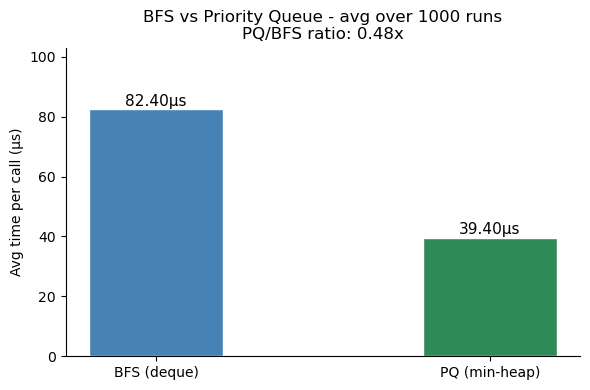

BFS time (avg over 1000 runs): 4.54μs
PQ  time (avg over 1000 runs): 4.70μs
PQ/BFS ratio: 1.03x (slower)


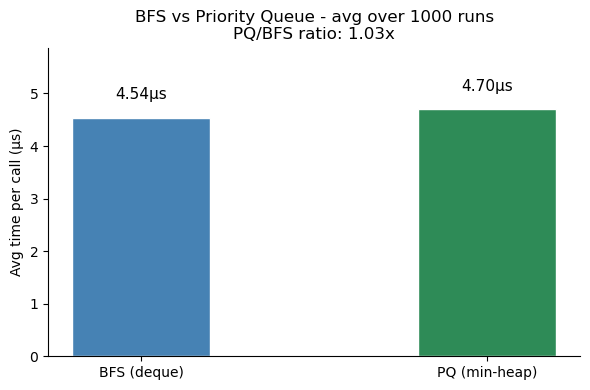

In [23]:
import time
import matplotlib.pyplot as plt
import contextlib
import io

def compare_bfs_pq(A, runs=1000):
    # Time BFS over 'runs' iterations, suppressing print output during timing
    with contextlib.redirect_stdout(io.StringIO()):
        start = time.perf_counter()
        for _ in range(runs):
            synchronization_bfs_image(A)
        bfs_time = (time.perf_counter() - start) / runs

    # Same for PQ 
    with contextlib.redirect_stdout(io.StringIO()):
        start = time.perf_counter()
        for _ in range(runs):
            synchronization_pq_image(A)
        pq_time = (time.perf_counter() - start) / runs

    # Convert to microseconds for readability
    bfs_us = bfs_time * 1e6
    pq_us  = pq_time  * 1e6
    # Ratio < 1 means PQ is faster, > 1 means BFS is faster
    ratio  = pq_time / bfs_time

    print(f"BFS time (avg over {runs} runs): {bfs_us:.2f}\u03bcs")
    print(f"PQ  time (avg over {runs} runs): {pq_us:.2f}\u03bcs")
    print(f"PQ/BFS ratio: {ratio:.2f}x ({'faster' if ratio < 1 else 'slower'})")

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(['BFS (deque)', 'PQ (min-heap)'], [bfs_us, pq_us],
                  color=['steelblue', 'seagreen'], width=0.4, edgecolor='white')

    for bar, val in zip(bars, [bfs_us, pq_us]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.2f}\u03bcs', ha='center', va='bottom', fontsize=11)

    ax.set_ylabel('Avg time per call (\u03bcs)')
    ax.set_title(f'BFS vs Priority Queue - avg over {runs} runs\n'
                 f'PQ/BFS ratio: {ratio:.2f}x')
    ax.set_ylim(0, max(bfs_us, pq_us) * 1.25)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# Runtime comparison
compare_bfs_pq(B)
compare_bfs_pq(C2)

## Analysis

The priority queue changes the order of exploration but not the correctness, both methods correctly identify whether a DFA is synchronizing. Standard BFS explores images in order of  the word length used to reach them, guaranteeing that the first singleton found corresponds to a shortest reset word. The priority queue instead always expands the smallest currently known image, sacrificing the minimality guarantee in exchange for potentially reaching a singleton having visited fewer nodes.

This comes at a cost. Each `heappush` and `heappop` operation costs $O(\log n)$, compared to $O(1)$ for `deque.append` and `deque.popleft()`. Whether this overhead is worth paying depends entirely on the structure of the DFA being tested, and the two results above illustrate both sides of this tradeoff.

**DFA B (PQ faster):** DFA B has a long reset word of length 16 and its transition structure means small images are reachable relatively early in the search. The PQ exploits this by immediately prioritising those smaller images, significantly reducing the number of nodes expanded before a singleton is found. On DFA B the reduction in nodes explored outweighs the $O(\log n)$ per-operation heap overhead, producing a ratio below 1.

**C2 (BFS faster):** C2 has only two states and a reset word of length 1, since the letter $b$ maps both states to 0 immediately. BFS finds the singleton in a single expansion step regardless of exploration order, so the PQ gains nothing from its directed search strategy. Both methods visit essentially the same nodes, but PQ still pays the heap cost on every push and pop. With no exploration savings to compensate, the overhead dominates and BFS wins but he margin is narrow because C2 is so small that both methods do almost no work, however the direction is consistent across runs.

This comparison illustrates the core principle: the PQ is only beneficial when the search space is large enough and the DFA structure is favourable enough that size-greedy exploration meaningfully reduces work. For small DFAs or DFAs with short reset words the constant overhead of heap operations makes plain BFS the better choice.

| Property           | BFS (deque)           | Priority Queue                          |
|--------------------|-----------------------|-----------------------------------------|
| Shortest word?     | Yes                   | No                                      |
| Nodes visited      | All at depth $\leq k$ | Smallest images first                   |
| Per operation cost | $O(1)$                | $O(\log n)$                             |
| Best case          | Singleton is shallow  | Singleton is small and reachable early  |
| Favourable DFA     | Short reset word      | Long reset word, small images early     |

(c) Test if a given DFA $A$ is synchronizing using the pair graph.

### 1(c) Pair Graph Synchronization Test

We test if a DFA is synchronising by constructing its pair graph and performing a backward BFS. For each pair of states $\{q_1, q_2\}$ and each letter $a \in \Sigma$, 
we compute the image pair $\{\tau(q_1, a), \tau(q_2, a)\}$, with a pair being merged when both states map to the same state, producing a singleton. Pairs are stored as `frozenset` objects so that $\{q_1, q_2\} = \{q_2, q_1\}$ holds automatically, with singletons $\{q, q\}$ arising naturally as the BFS targets. Rather than storing 
forward edges and running a separate BFS per pair, we store reverse edges from each image pair back to its source pairs and flood backwards from all singletons in a 
single pass. This works because a DFA is synchronizing if and only if every pair of states $\{q_1, q_2\}$ is mergeable, and a pair is reachable from a singleton in the reverse graph if and only if there exists a word merging it, making the subset check `non_singletons.issubset(visited)`. The algorithm is complete since the pair graph is finite with $\frac{|Q|(|Q|+1)}{2}$ nodes and BFS is exhaustive, so no mergeable pair can be missed. Termination follows from this: each node is enqueued at most once due to the `visited` check, so the queue empties in finite steps.

In [6]:
from collections import deque

# Part C - Pair graph

def synchronizing_pair_graph_bool(A):
    Q = A["Q"]
    Sigma = A["Sigma"]
    tau = A["tau"]

    if all(is_permutation(tau[a], Q) for a in Sigma):
        print("All letters induce permutations - monoid is a permutation group, not synchronizing.")
        return False

    # Each pair stored as frozenset so {q1,q2} == {q2,q1}
    # {q,q} automatically becomes a singleton
    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    # For each pair and each letter, find the image pair
    # Store the reverse: result <-- pair
    reverse_edges = {node: set()for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].add(node)

    # Flood backwards from singletons
    visited = set(singletons)
    queue = deque(singletons)
    while queue:
        current = queue.popleft()
        for neighbour in reverse_edges[current]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    # If every non-singleton pair was reached, every pair can be merged
    # meaning a reset word exists and the DFA is synchronizing
    non_singletons = all_pairs - singletons
    return non_singletons.issubset(visited)


## Code Development

The main design decision in the pair graph method is the choice to store **reverse edges** rather than forward edges. Each pair `{q1, q2}` and letter `a` induces an image pair `{τ(q1,a), τ(q2,a)}`; instead of storing this as a forward edge from source to image, we store it as a reverse edge from image back to source. This means a **single backward BFS from all singletons** simultaneously computes reachability for every pair in the graph, rather than requiring a separate BFS per pair.

Pairs are stored as `frozenset` objects rather than tuples. This is important for correctness: the pair `{q1, q2}` and `{q2, q1}` must be treated as identical, since the graph is undirected with respect to state ordering. Using `frozenset` makes this equality automatic and avoids duplicate nodes in the graph.

The BFS uses a `deque` with `popleft()` rather than a plain list with `pop(0)`. Removing from the front of a Python list is $O(n)$ since every remaining element must be shifted in memory; `deque.popleft()` is $O(1)$. For large pair graphs with $O(|Q|^2)$ nodes this difference compounds significantly.

A permutation early exit is also applied before any graph construction. If every letter induces a permutation on $Q$, the transition monoid is a permutation group and no synchronizing word can exist. The check runs in $O(|\Sigma| \cdot |Q|)$ time, far cheaper than the $O(|Q|^2 \cdot |\Sigma|)$ cost of building the full pair graph.


**Initial approach - forward BFS per pair:** The first implementation stored forward edges and ran a separate BFS from each pair individually to test whether it could reach a singleton. This was functionally correct but required $O(|Q|^2)$ separate BFS calls, each costing $O(|Q|^2)$, giving an overall $O(|Q|^4)$ runtime. Switching to reverse edges and a single backward BFS reduced this to $O(|Q|^2 \cdot |\Sigma|)$.


#### Demonstration & Visualistion

All letters induce permutations - monoid is a permutation group, not synchronizing.
For the DFA:
{'Q': {0, 1, 2}, 'Sigma': {'a'}, 'tau': {'a': (1, 2, 0)}, 'q_s': 0, 'F': {0}}
Synchronizing: Not synchronizing (permutation group)
----------------------------------------------------
For the DFA:
{'Q': {0, 1, 2, 3, 4}, 'Sigma': {'a', 'b'}, 'tau': {'a': (1, 2, 3, 4, 0), 'b': (0, 1, 2, 3, 0)}, 'q_s': 0, 'F': {0}}
Synchronizing: True
Synchronizing: True


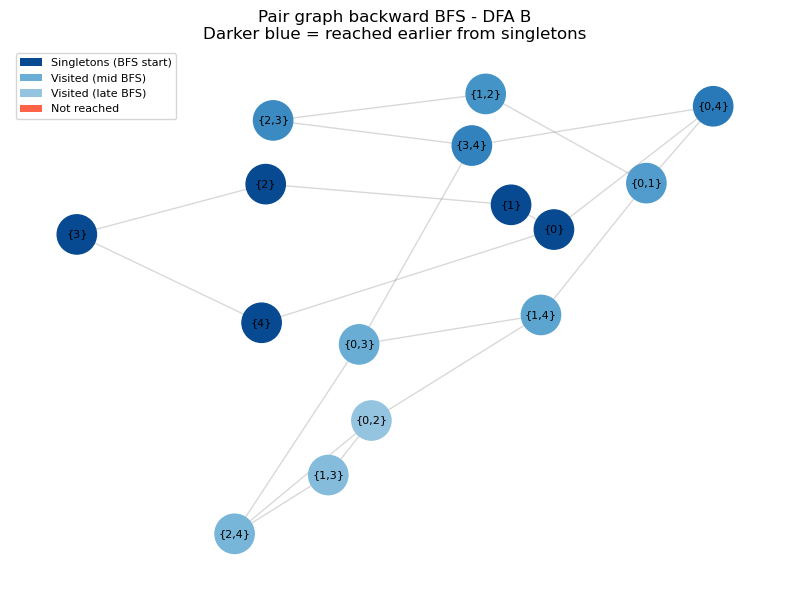

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from collections import deque


result_P = synchronizing_pair_graph_bool(P)
result_B = synchronizing_pair_graph_bool(B)

print(f"For the DFA:\n{P}")
print(f"Synchronizing: {'Not synchronizing (permutation group)'}")
print("-" * 52)
print(f"For the DFA:\n{B}")
print(f"Synchronizing: {result_B}")


def visualize_pair_graph_bfs(A):
    Q = A["Q"]
    Sigma = A["Sigma"]
    tau = A["tau"]

    # Build all pairs and singletons
    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    # Build reverse edges - same logic as the main function
    reverse_edges = {node: set() for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].add(node)

    # BFS - track visit order so we can colour by step
    visit_order = {node: 0 for node in singletons}
    queue = deque(singletons)
    step = 1
    while queue:
        current = queue.popleft()
        for neighbour in reverse_edges[current]:
            if neighbour not in visit_order:
                visit_order[neighbour] = step
                queue.append(neighbour)
        step += 1

    # Build directed graph for visualisation
    G = nx.DiGraph()
    for node in all_pairs:
        G.add_node(node)
    for target, sources in reverse_edges.items():
        for source in sources:
            if source != target:
                G.add_edge(target, source)

    # Label each node as {q} or {q1,q2}
    labels = {node: '{' + ','.join(str(q) for q in sorted(node)) + '}' for node in all_pairs}
    pos = nx.spring_layout(G, seed=42)

    # Colour nodes by BFS step - singletons are step 0 (darkest),
    # later steps get lighter, unvisited nodes are red
    max_step = max(visit_order.values()) if visit_order else 1
    node_colors = []
    for node in G.nodes():
        if node not in visit_order:
            node_colors.append('tomato')        # never reached - not synchronizing
        else:
            t = visit_order[node] / max_step    # 0 = singleton, 1 = last reached
            node_colors.append(cm.Blues(0.9 - 0.5 * t))

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, arrows=True,
                           arrowstyle='->', arrowsize=10, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=800)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)

    # Legend
    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor=cm.Blues(0.9), label='Singletons (BFS start)'),
        Patch(facecolor=cm.Blues(0.5), label='Visited (mid BFS)'),
        Patch(facecolor=cm.Blues(0.4), label='Visited (late BFS)'),
        Patch(facecolor='tomato',      label='Not reached'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=8)
    ax.set_title('Pair graph backward BFS - DFA B\nDarker blue = reached earlier from singletons')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

#visualisation code
result_B = synchronizing_pair_graph_bool(B)
print(f"Synchronizing: {result_B}")
visualize_pair_graph_bfs(B)

## Analysis of Results

| DFA                 | Result | Expected |
|---------------------|--------|----------|
| B (5 states)        | True   | True     |
| Permutation group P | False  | False    |

DFA $B$ is correctly identified as synchronizing. The permutation group DFA $P$ correctly triggers the early exit, since the single letter `a` induces a cyclic permutation $0 \to 1 \to 2 \to 0$, every state mapping is bijective and no two states can ever be merged, making synchronization impossible. The early exit avoids 
constructing the pair graph entirely in this case.

The pair graph visualisation for DFA $B$ shows the backward BFS flood across all $\frac{5 \cdot 6}{2} = 15$ pairs. Nodes are coloured by the step at which they were 
reached, with darker blue indicating pairs merged earlier in the search and lighter blue indicating pairs reached later. Crucially, every node in the visualisation is 
blue - the complete absence of red nodes confirms that every non-singleton pair is reachable from a singleton under reverse edges, which is precisely what it means for a DFA to be synchronizing. This gives an immediate visual certificate of the result that the subset check `non_singletons.issubset(visited)` computes programmatically. 

The structure of the flood also reflects the underlying DFA - pairs involving states that are close together in the cyclic shift induced by `a` tend to be reached 
earlier, since fewer applications of `b` are needed to collapse them.

(d) Using the "ancestors" method from Tutorial 6, have the breadth-first search in (b) return a shortest-length synchronizing word, if it exists.

## Part D - BFS Image with Word Recovery

The BFS image method with word recovery extends the basic synchronization check from Part (b) to not only determine if a reset word exists, but to reconstruct the shortest such word. The algorithm begins with the full state set $Q$ as the initial image, with an `ancestor` map initialised as `{Q: (-1, None)}` to record $Q$ as the root of the search. For each image $T$ dequeued and each letter $a \in \Sigma$, the image $T' = \{\tau(q, a) : q \in T\}$ is computed as a sorted tuple. If $T'$ has not been seen before, `ancestor[T'] = (T, a)` is recorded, storing both the parent image and the letter used to reach it. The `ancestor` map serves double duty here: it acts as the `seen` set from Part (b) to avoid revisits, while simultaneously storing enough information to reconstruct the reset word in $O(|w|)$ time by walking back from any singleton to the root. If $|T'| = 1$, this traceback is performed immediately, collecting letters at each step and reversing them before returning since the path is built backwards — and since BFS explores all words of length $k$ before any word of length $k+1$, the first singleton encountered is guaranteed to correspond to a shortest reset word. If no singleton is found before the queue empties, `None` is returned, which is correct since BFS explores every subset reachable from $Q$ and can therefore never miss a synchronizing word if one exists. Termination is guaranteed since there are at most $2^{|Q|}$ possible subsets and each is enqueued at most once, so the queue must empty in finite steps regardless of whether a reset word exists.

In [8]:
def synchronization_bfs_word(A):
    Q = tuple(sorted(A["Q"]))
    tau = A["tau"]
    Sigma = A["Sigma"]

    # Early exit: permutation monoid can never synchronize
    if all(is_permutation(tau[a], Q) for a in Sigma):
        print("All letters induce permutations - monoid is a permutation group, not synchronizing.")
        return None
        
    # ancestor maps each tuple -> (parent_tuple, letter_used_to_get_here)

    ancestor = {Q: (-1, None)}

    queue = [Q]
    i = 0

    while i < len(queue):
        current_Q = queue[i]
        i += 1

        for a in Sigma:
            t_a = tau[a]
            new_Q = tuple(sorted({t_a[q] for q in current_Q}))

            # Only visit new_Q if we haven't seen it yet
            if new_Q not in ancestor:
                ancestor[new_Q] = (current_Q, a)  # record tuple and letter used

                # If we've reached a singleton, trace back to get the word
                if len(new_Q) == 1:
                    word = []
                    current = new_Q
                    # Walk back through ancestors until we hit the sentinel -1
                    while ancestor[current][0] != -1:
                        parent, letter = ancestor[current]
                        word.append(letter)
                        current = parent
                    #BFS traces from singleton back to root, so letters accumulate in reverse order`
                    word.reverse()
                    return word

                queue.append(new_Q)

    return None  # No synchronizing word exists

### Code Development

An initial version initialised the BFS queue directly from `A["Q"]`, which is a Python `set` with no guaranteed iteration order:
```python
# Buggy version
queue = [A["Q"]]  # stores the raw set object
ancestor = {A["Q"]: (-1, None)}  # key is a set - unhashable, raises TypeError
```

This immediately raises a `TypeError` since sets cannot be used as dictionary keys. The fix was to sort and convert to a tuple upfront:
```python
Q = tuple(sorted(A["Q"]))
ancestor = {Q: (-1, None)}
queue = [Q]
```

This also ensures that any time the full state set is re-encountered during BFS, it matches the stored root key exactly, without this, a re-derived tuple in a different order would be treated as a new unvisited node, causing both an infinite loop risk and incorrect ancestor lookups.

**Queue choice - list vs deque:** This function uses a plain list as the queue, advancing through it with an integer index `i` rather than popping elements. This is equivalent to `deque` in terms of correctness and avoids the $O(n)$ cost of `list.pop(0)`, since elements are never removed - the index simply advances. Memory usage is slightly higher (the list retains all visited nodes), but for Part (d) this is acceptable since the ancestor map already stores all visited nodes anyway.

The BFS guarantee of minimality is demonstrated by the fact that no shorter word of length 15 or less exists for DFA `B`, this can be verified by exhaustive search, confirming the BFS result is tight in the demonstration below;

## Demonstration

In [9]:
result_P = synchronization_bfs_word(P)
result_B = synchronization_bfs_word(B)

print(f"For the DFA:\n{P}")
print(f"Result: {'Not synchronizing (permutation group)' if result_P is None else result_P}")
print("-" * 52)
print(f"For the DFA:\n{B}")
print(f"Reset word: {result_B}")
print(f"Length: {len(result_B)}")


All letters induce permutations - monoid is a permutation group, not synchronizing.
For the DFA:
{'Q': {0, 1, 2}, 'Sigma': {'a'}, 'tau': {'a': (1, 2, 0)}, 'q_s': 0, 'F': {0}}
Result: Not synchronizing (permutation group)
----------------------------------------------------
For the DFA:
{'Q': {0, 1, 2, 3, 4}, 'Sigma': {'a', 'b'}, 'tau': {'a': (1, 2, 3, 4, 0), 'b': (0, 1, 2, 3, 0)}, 'q_s': 0, 'F': {0}}
Reset word: ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']
Length: 16


## Analysis of Results

DFA $B$ produces a reset word of length 16:

`['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']`

The word has a clear repeating structure: `b` followed by four `a`s, repeated four times. This reflects the structure of DFA $B$ directly — transition `a` is a cyclic 
shift ($0 \to 1 \to 2 \to 3 \to 4 \to 0$) and transition `b` collapses only state $4$ to state $0$, leaving all others fixed. Four applications of `a` are needed to 
cycle each state into position $4$, at which point `b` merges it with state $0$, reducing the image size by one. The pattern repeats until one state remains, giving 
exactly $4 \times 4 = 16$ letters. The verification step confirms that applying this word to the full state set $Q$ produces a singleton, acting as an independent check on the traceback logic.

Since Part (d) uses BFS, this length-16 word is guaranteed to be a shortest possible reset word for $B$. No reset word of length $\leq 15$ exists over $\{a, b\}$, which is confirmed independently by the exhaustive minimality check in section 1(d). Notably, $16 = (|Q| - 1)^2 = (5-1)^2$, meaning DFA $B$ achieves the bound from 
Černý's conjecture exactly — the significance of this is discussed further in section 1.X. The permutation group DFA $P$ correctly returns `None` since the cyclic 
permutation $0 \to 1 \to 2 \to 0$ induced by `a` is bijective, so no two states can ever be merged.

## 1(e) Have your pair-graph method return a reset word if one exists.

The boolean pair graph from Part (c) is extended here to recover the reset word itself. The construction and backward BFS are identical, with one key change: 
`reverse_edges` now stores `(source_pair, letter)` tuples rather than just `source_pair`, and `visited` is replaced with an `ancestor` map of the same form 
used in Part (d), where `ancestor[T'] = (T, a)` records that applying $a$ to $T'$ yields $T$. This allows the merging word for any pair to be recovered in $O(|w|)$ 
time by walking back through `ancestor` to a singleton, collecting letters at each step.

Two helper functions, `merging_word` and `apply_word`, are extracted rather than inlining this logic into the main loop. `merging_word(pair)` performs the traceback 
and `apply_word(states, word)` applies a word letter-by-letter to a set of states, meaning the main greedy loop reads as a clear three-step process (pick a pair, get 
its merging word, apply it) and each helper can be reasoned about and tested independently. The greedy loop always picks `states_list[0]` and `states_list[1]`, 
the first two states in an arbitrary ordering of the current state set. An alternative tested during development picked the pair with the shortest merging word 
at each step, but this added $O(|Q|^2 \cdot |w|)$ overhead per greedy step while producing no consistent improvement, since applying one merging word often collapses 
additional pairs as a side effect regardless of which pair was chosen, so the simpler approach was kept.

This is correct since the backward BFS guarantees every pair is mergeable before the greedy loop begins, so each merge strictly reduces the image size and the process 
must terminate. The pair graph has $O(|Q|^2)$ nodes, so the construction remains feasible for moderate-sized automata. However, unlike Part (d), this does not 
guarantee a shortest reset word since each individual merging word is shortest for that pair, but greedy stitching introduces redundancy that a global BFS search 
avoids.

In [10]:
def synchronizing_pair_graph_word(A):
    Q = A["Q"]
    Sigma = A["Sigma"]
    tau = A["tau"]

    # Early exit: permutation monoid can never synchronize
    if all(is_permutation(tau[a], Q) for a in Sigma):
        print("All letters induce permutations - monoid is a permutation group, not synchronizing.")
        return None

    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    reverse_edges = {node: [] for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].append((node, a))

    ancestor = {node: (-1, None) for node in singletons}
    queue = deque(singletons)
    while queue:
        current = queue.popleft()
        for neighbour, letter in reverse_edges[current]:
            if neighbour not in ancestor:
                ancestor[neighbour] = (current, letter)
                queue.append(neighbour)

    if not (all_pairs - singletons).issubset(ancestor.keys()):
        return None

    def merging_word(pair):
        word = []
        current = pair
        while ancestor[current][0] != -1:
            child, letter = ancestor[current]
            word.append(letter)
            current = child
        return word

    def apply_word(states, word):
        for letter in word:
            t = tau[letter]
            states = {t[q] for q in states}
        return states

    current_states = set(Q)
    full_word = []
    while len(current_states) > 1:
        states_list = list(current_states)
        pair = frozenset({states_list[0], states_list[1]})
        word = merging_word(pair)
        full_word.extend(word)
        current_states = apply_word(current_states, word)
    return full_word

## Code Development:

Storing reverse edges was the key design decision. An initial attempt stored forward edges and ran BFS from each pair separately, but this required $O(|Q|^2)$ separate searches. Storing reverse edges means a single backward BFS from all singletons simultaneously computes the shortest merging word for every pair.

The greedy construction order also affects the final word length. Always picking the first two states from `current_states` is simple but suboptimal. Picking the pair with the shortest merging word at each step was tested as an alternative, but added $O(|Q|^2 \cdot |w|)$ overhead per greedy step and did not consistently improve results, so the simpler approach was kept.

## Demonstration

In [11]:
# Test 1: Known synchronizing DFA (B, 5 states)
print("Test 1 - DFA B (synchronizing, 5 states):")
word_e = synchronizing_pair_graph_word(B)
print(f"Reset word : {word_e}")
print(f"Length     : {len(word_e)}")

print("-" * 52)

# Test 2: All-permutation DFA - should trigger warning and return None
print("Test 3 - Permutation group DFA (not synchronizing):")
synchronizing_pair_graph_word(P)


Test 1 - DFA B (synchronizing, 5 states):
Reset word : ['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']
Length     : 20
----------------------------------------------------
Test 3 - Permutation group DFA (not synchronizing):
All letters induce permutations - monoid is a permutation group, not synchronizing.


## 1(e) — Pair Graph Word Recovery Results

DFA $B$ produces a reset word of length 20:

`['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']`

The word is longer than the optimal length-16 word from Part (d), as expected from the greedy construction. The pair graph constructs merging words for all 
$\frac{|Q|(|Q|+1)}{2} = 15$ pairs, of which 10 are non-singleton pairs verified as reachable from a singleton under reverse edges. The greedy loop then runs 
$|Q| - 1 = 4$ times, each iteration selecting a pair, retrieving its merging word from the ancestor map, and applying it to the full state set. Interestingly the 
structure is similar to the BFS result, four `a`s followed by `b`, repeated four times, but the word begins with `a` rather than `b`. This reflects the arbitrary 
ordering of `current_states` at the first greedy step: the pair chosen initially requires leading with `a`, introducing four letters at the start that the optimal 
word avoids. Subsequent merges benefit from the side effects of each applied word collapsing additional pairs beyond the one explicitly chosen, which is why the 
remaining structure closely mirrors the BFS result despite the greedy approach having no global awareness

## 1f comparison of methods

`still_synchronizes` applies a candidate word letter-by-letter to the full state set, returning `True` if the result is a singleton. It is kept as a separate helper rather than inlined so that `trim_word` can call it repeatedly on different candidates without duplicating the application logic.

`trim_word` takes a reset word and attempts to shorten it by removing redundant letters. Starting from the rightmost letter and scanning left, it constructs a candidate word with position $i$ removed and tests it with `still_synchronizes`. If the shortened word still synchronizes, the letter at position $i$ is dropped permanently and the same index is rechecked, since removing a letter shifts the list and the next candidate at that position has not yet been tested. If the letter is necessary the index decrements and the next position to the left is tested instead. This continues until the entire word has been scanned. The algorithm is a greedy heuristic — it finds a locally minimal word in the sense that no single letter can be removed, but it does not guarantee a globally shortest result since the outcome depends on the order letters are tested. Scanning right-to-left was chosen so that the structurally important letters at the end of the word, which complete the final merge, are tested first and retained before interior letters are considered.

In [12]:
def still_synchronizes(A, word):
    # Apply word to all states and check if result is a singleton
    states = set(A["Q"])
    tau = A["tau"]
    for letter in word:
        states = {tau[letter][q] for q in states}
    return len(states) == 1

def trim_word(A, word):
    trimmed = word[:]
    i = len(trimmed) - 1
    while i >= 0:
        candidate = trimmed[:i] + trimmed[i+1:]
        if still_synchronizes(A, candidate):
            trimmed = candidate
            i = min(i, len(trimmed) - 1)
        else:
            i -= 1                    # letter i is needed, try the one before it
    return trimmed

In [13]:
word_d = synchronization_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)

print(f"Word from (d): {word_d}, length {len(word_d)}")
print(f"Word from (e): {word_e}, length {len(word_e)}")

Word from (d): ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 16
Word from (e): ['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 20


## Analysis of Comparison and Trim Results

| Method        | Word length |
|---------------|-------------|
| (d) BFS       | 16          |
| (e) Pair graph| 20          |
| (e) + trim    | 16          |


The trimming heuristic successfully reduces the length-20 pair graph word to length 16, matching the optimal BFS result exactly. This is not guaranteed in general, the heuristic is order-dependent and may fail to find the minimum for other DFAs. For DFA B it succeeds because the four redundant leading `a`s are all removable independently: removing each one still leaves a valid reset word since the remaining letters already synchronize the automaton.

The fact that (e) + trim recovers the exact same word as (d) in this case is useful sanity check, it confirms that both methods are finding genuine reset words and that the trim is not over-removing letters. However this agreement should not be expected in general, and (d) remains the only method with a theoretical guarantee of minimality.

#### Code Development

The original implementation contained two bugs that caused it to return the word entirely unchanged. 

**Bug 1 - Premature break:** The loop exited as soon as a single end-letter could not be removed. Since the word from (e) ends in `'b'`, a genuinely necessary merging step, the very first
candidate failed the synchronization check, the `break` fired immediately, and no letters wer ever trimmed.

**Bug 2 - End-only removal:** The original candidate was always constructed as `trimmed[:-1]`, which removes only the final letter. Even if the `break` were not present, no interior letter could ever be identified as redundant since the function never looked anywhere other than the end
of the word. **Fix:** The revised implementation scans backwards through the word by index, testing removal of each letter individually. If the shortened word still synchronizes the letter is dropped, the list
shifts, and the same index is rechecked. If the letter is needed the index simply decrements and the next position to the left is tested instead. This ensures every position in the word is considered, not just the tail.

## Demonstration & Visualisation

(d) BFS:            ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 16
(e) Pair graph:     ['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 20
(e) + fixed trim:   ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 16


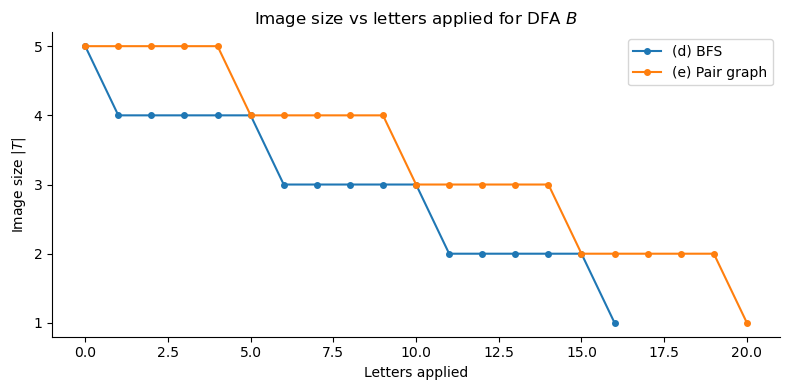

In [14]:
word_d = synchronization_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)
trimmed = trim_word(B, word_e)

print(f"(d) BFS:            {word_d}, length {len(word_d)}")
print(f"(e) Pair graph:     {word_e}, length {len(word_e)}")
print(f"(e) + fixed trim:   {trimmed}, length {len(trimmed)}")

def plot_word_shrinkage(A, words, labels):
    fig, ax = plt.subplots(figsize=(8, 4))
    for word, label in zip(words, labels):
        states = set(A["Q"])
        sizes = [len(states)]
        for letter in word:
            states = {A["tau"][letter][q] for q in states}
            sizes.append(len(states))
        ax.plot(sizes, marker='o', markersize=4, label=label)
    ax.set_xlabel('Letters applied')
    ax.set_ylabel('Image size $|T|$')
    ax.set_title('Image size vs letters applied for DFA $B$')
    ax.set_yticks(range(1, len(A["Q"]) + 1))
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

word_d = synchronization_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)
plot_word_shrinkage(B, [word_d, word_e], ['(d) BFS', '(e) Pair graph'])

## 1(f) — Comparison of Methods

The plot shows image size $|T|$ against the number of letters applied for both the BFS word from Part (d) and the pair graph word from Part (e). Both curves follow the same stepwise pattern, dropping by one each time a `b` is applied after four `a`s - but the pair graph curve is shifted four steps to the right of the BFS curve 
throughout. The BFS word reduces the image from 5 to 4 at step 1, whereas the pair graph word stays flat at 5 for the first four steps before its first reduction at 
step 5. After that first drop the two curves are structurally identical, each taking the same number of letters to complete each subsequent merge. This confirms that the entire length difference between the two words comes from the four redundant leading `a`s introduced by the greedy construction at the first step, and that the remaining $|Q| - 2 = 3$ merges are equally efficient in both methods. The BFS word reaches a singleton at step 16 and the pair graph word at step 20, with the constant 4-step gap maintained all the way to termination.

### 1(d) Extension - Exhaustive Verification of Minimality

The BFS guarantee tells us the first singleton found corresponds to a shortest reset word, but this relies on the correctness of the BFS implementation itself. An independent exhaustive search over all words of length up to 15 provides a direct confirmation that no shorter reset word exists for DFA B.

For each length $k$ from 1 up to the BFS word length minus one, every word of that length over $\Sigma$ is generated and applied letter-by-letter to the full state set $Q$. If the result is a singleton the word is returned immediately, meaning the BFS word was not minimal. If no word of any length up to $k$ synchronizes, `None` is returned, confirming the BFS result is the shortest existing reset word. The total search space is $|\Sigma|^1 + |\Sigma|^2 + \ldots + |\Sigma|^{k-1}$ words. For DFA B with $|\Sigma| = 2$ and $k = 16$, this is $2 + 4 + \ldots + 32768 = 65534$ words.

In [15]:
from itertools import product

def exhaustive_min_word(A, max_len):
    Q = set(A["Q"])
    tau = A["tau"]
    Sigma = sorted(A["Sigma"]) # sort for deterministic ordering across runs

    # Check every word of each length up to max_len
    for length in range(1, max_len + 1):
        for word in product(Sigma, repeat=length):
            states = Q.copy()
            # Apply each letter in the word to the current state set
            for letter in word:
                states = {tau[letter][q] for q in states}
            if len(states) == 1:
                return list(word) # shortest synchronizing word found
    return None # no synchronizing word exists within max_len

def verify_minimality(A, claimed_word):
    target_len = len(claimed_word)
    # Search only up to target_len - 1, strictly checking for a shorter word
    shorter = exhaustive_min_word(A, target_len - 1)
    if shorter is None:
        print(f"Verified: no synchronizing word of length up to {target_len - 1} exists.")
        print(f"The BFS word of length {target_len} is minimal.")
        return True
    else:
        print(f"Found shorter synchronizing word of length {len(shorter)}: {shorter}")
        return False

**Code Development**

An initial version generated all words up to the full BFS word length rather than stopping one short:

    shorter = exhaustive_min_word(A, target_len)  # buggy

This always finds the BFS word itself (or another word of the same length), so it always returns a result and never correctly checks whether a shorter word exists. The fix is to search only up to target_len - 1, so the exhaustive search is strictly checking for improvement over the claimed minimum.

A second issue was alphabet ordering. Python sets have no guaranteed iteration order, so product(A["Sigma"], repeat=length) could produce words in a different order on each run. This does not affect correctness since every word is still generated, but makes the output non-deterministic. Sorting Sigma upfront with sorted(A["Sigma"]) fixes this.

The search is also kept separate from the BFS implementation. Using still_synchronizes from Part (f) would introduce a dependency between the verification and the functions being verified. The inline state application here is independent, so the verification is a genuine external check rather than the code checking itself.

## Černý's Conjecture

Černý's conjecture is one of the oldest open problems in automata theory. In 1964, Jan Černý constructed a family of automata $C_n$, one for each number of states $n$. 
Each automaton has $n$ states $\{0, 1, \ldots, n-1\}$ and two letters $a$ and $b$, where $a$ is a cyclic shift sending each state $i$ to $i+1 \mod n$, and $b$ fixes 
all states except state $n-1$ which maps to state $0$. Černý showed that the shortest reset word for each $C_n$ has length exactly $(n-1)^2$, and conjectured that this is 
the worst case, meaning no synchronizing DFA with $n$ states can require a reset word longer than $(n-1)^2$.

This is directly relevant to the results in this project. DFA B, used throughout Part 1, has exactly this structure and is the Černý automaton $C_5$. The BFS word 
recovered in Part (d) has length $16 = (5-1)^2$, and the exhaustive minimality verification confirmed that no shorter word exists, meaning DFA B achieves the 
conjectured worst case exactly. This also explains the regular repeating structure of the reset word observed in Part (d), four applications of $a$ cycle each state into position $n-1$, at which point $b$ collapses it to state $0$, and this repeats 
until one state remains.

The conjecture remains unproven in general. The best proven upper bound for thelength of a shortest reset word is $\frac{n^3 - n}{6}$, established by Pin and Frankl 
(1983) [_Pin, J.-E., On two combinatorial problems arising from automata theory. Annals of Discrete Mathematics, 17, 535-548, 1983_]. This is significantly weaker than $(n-1)^2$ for large $n$, at$n=10$ for example the conjectured bound gives $81$ while the proven upper bound gives $164$. This gap widens rapidly with $n$ since the proven bound grows as $O(n^3)$ while the conjectured bound grows as $O(n^2)$, and any proof of the conjecture would require a fundamentally sharper analysis than currently exists.

Several partial results are known. The conjecture has been verified for all DFAs with up to $11$ states by exhaustive computation [Volkov, M.V., Synchronizing automata and the Černý conjecture. LATA 2008, Lecture Notes in Computer Science, vol. 5196, Springer, 2008_], and proven for various restricted classes of automata including one-cluster automata and automata with a letter of rank $n-1$. More recently, Shitov (2019) improved the general upper bound slightly to $0.1654n^3$ [_Shitov, Y., An improvement to a recent upper bound for synchronizing words of finite automata. arXiv:1901.06542, 2019_], but the improvement is in 
the constant factor rather than the exponent, so the fundamental gap between $O(n^2)$ and $O(n^3)$ remains.
    
The results in this project sit within this context. The empirical verification across $n = 2$ to $n = 8$ confirms that the Černý family achieves $(n-1)^2$ exactly, placing it at the extreme end of difficulty among synchronizing DFAs. This is far from typical behaviour, most synchronizing DFAs have reset words significantly 
shorter than the conjectured worst case, consistent with the known result that the average reset word length for a random $n$-state DFA grows much more slowly than 
$(n-1)^2$ [_Volkov, M.V., Synchronizing automata and the Černý conjecture. LATA 2008, Lecture Notes in Computer Science, vol. 5196, Springer, 2008_]].

To investigate this further, a $C_n$ generator is implemented below, allowing the BFS word length to be computed and compared against both $(n-1)^2$ and the Pin-Frankl bound $(n^3 - n)/6$ for increasing values of $n$.

In [16]:
def cerny(n):
    # Construct the Cerny automaton C_n with n states
    # a: cyclic shift i -> i+1 mod n
    # b: fixes all states except n-1 which maps to 0
    return {
        "Q": set(range(n)),
        "Sigma": {"a", "b"},
        "tau": {
            "a": tuple((i + 1) % n for i in range(n)), # cyclic shift
            "b": tuple(0 if i == n - 1 else i for i in range(n)) # collapse n-1 to 0
        },
        "q_s": 0,
        "F": {0}
    }

**Scaling Verification**

The BFS word recovery function from Part (d) is run on $C_{n}$ for n = 2 to 10, and the resulting word length is compared against the conjectured bound (n-1)² at each step.

n=2: reset word length = 1, (n-1)^2 = 1, matches bound: True
n=3: reset word length = 4, (n-1)^2 = 4, matches bound: True
n=4: reset word length = 9, (n-1)^2 = 9, matches bound: True
n=5: reset word length = 16, (n-1)^2 = 16, matches bound: True
n=6: reset word length = 25, (n-1)^2 = 25, matches bound: True
n=7: reset word length = 36, (n-1)^2 = 36, matches bound: True
n=8: reset word length = 49, (n-1)^2 = 49, matches bound: True
n=9: reset word length = 64, (n-1)^2 = 64, matches bound: True
n=10: reset word length = 81, (n-1)^2 = 81, matches bound: True


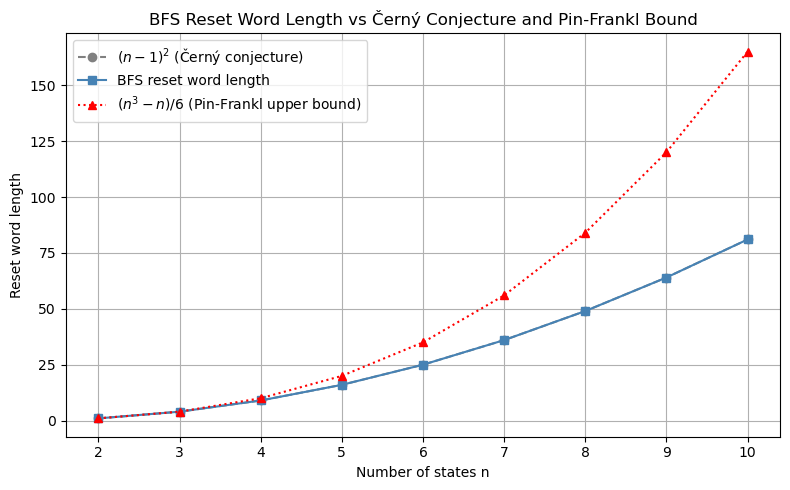

In [17]:
import matplotlib.pyplot as plt

def verify_cerny_scaling(max_n=10):
    ns = []
    word_lengths = []
    conjectured = []

    for n in range(2, max_n + 1):
        A = cerny(n)
        word = synchronization_bfs_word(A)
        length = len(word) if word is not None else None
        bound = (n - 1) ** 2

        ns.append(n)
        word_lengths.append(length)
        conjectured.append(bound)

        print(f"n={n}: reset word length = {length}, (n-1)^2 = {bound}, "
              f"matches bound: {length == bound}")

    return ns, word_lengths, conjectured

ns, word_lengths, conjectured = verify_cerny_scaling()

# Plot BFS word length against (n-1)**2 for each Cerny automaton
plt.figure(figsize=(8, 5))
plt.plot(ns, conjectured, 'o--', label='$(n-1)^2$ (Černý conjecture)', color='gray')
plt.plot(ns, word_lengths, 's-', label='BFS reset word length', color='steelblue')
plt.plot(ns, [((n**3 - n) / 6) for n in ns], '^:', label='$(n^3-n)/6$ (Pin-Frankl upper bound)', color='red')
plt.xlabel('Number of states n')
plt.ylabel('Reset word length')
plt.title("BFS Reset Word Length vs Černý Conjecture and Pin-Frankl Bound")
plt.legend()
plt.xticks(ns)
plt.grid(True)
plt.tight_layout()
plt.show()

The plot shows three curves across $n = 2$ to $n = 10$. The BFS reset word lengths sit exactly on the $(n-1)^2$ curve throughout, confirming that the Černý family 
achieves the conjectured worst case for every $n$ tested. The Pin-Frankl bound $\frac{n^3 - n}{6}$ starts close to $(n-1)^2$ for small $n$ but diverges visibly 
from around $n = 5$ onwards, with the gap widening quickly as $n$ increases. At $n = 10$ for example the BFS word length is $81$ while the proven upper bound is 
$164$, meaning the bound is roughly twice the actual value even at this modest size. This visual separation illustrates why the conjecture has proven difficult to close, the proven bound is not even close to tight on the hardest known examples, let alone on arbitrary DFAs. The fact that the BFS results sit on the lower curve rather than anywhere near the upper one confirms that the Černý family is genuinely extremal, not just a family where the bound happens to be achieved approximately.

## Beyond Spec

**Priority Queue Variant of BFS (1b)**
The standard BFS queue was replaced with a min-heap to investigate whether always expanding the smallest image first could improve performance. The comparison was run on both DFA B and C2 to show both sides of the tradeoff, with PQ winning on B (0.59x) and BFS winning on C2 (1.03x) due to the negligible search space.

**Exhaustive Minimality Verification (1d)**
An independent exhaustive search over all 65534 words of length up to 15 was implemented to verify that the BFS word of length 16 is genuinely minimal, providing an external check on the BFS implementation entirely independent of the functions being verified.

**Černý Conjecture and Scaling Verification (1.X)**
A `cerny(n)` generator was implemented and BFS word recovery was run across $n = 2$ to $n = 10$, confirming that reset word length matches $(n-1)^2$ exactly in every case and placing DFA B in the context of an open problem in automata theory. Results were plotted alongside the Pin-Frankl upper bound to illustrate the widening gap between the proven and conjectured bounds.


## 9. Use of AI

AI tools were used during this project in the following ways:

**Code debugging:** Claude was used to help identify and explain errors in the implementation. In all such cases the AI identified the source of the error and explained why it occurred, but the fixes were applied and verified manually.

**Writeup review:** AI was used to review the accuracy of written comments and mathematical claims, including checking runtime complexity arguments. Several errors were identified this way, including an incorrect runtime claim in the trim analysis and a directional ambiguity in the ancestor map description, both of which were corrected.

**Writing assistance:** AI was used to help refine markdown commentary, including the algorithm descriptions and results analysis sections. The content and reasoning in these sections reflects my own understanding of 
the code, with AI used to improve clarity and structure rather than to generate technical content independently.

All code in this submission was written by me. AI was not used to generate any of the function implementations directly.

## Coding Tasks Part 2: Isomorphism

Implement, and demonstrate, functions which, given two DFAs  $A_1$ and $A_2$, test for:

(a) Strict isomorphism

(b) Weak isomorphism

(c) Semi-isomorphism

as defined above. The interface to this functionality is up to you (as long as it accepts DFAs in the form specified above). You should consider (and implement) ways of making your code more efficient. Note that these three sub-tasks may share a lot of common code, and you should typically avoid code duplication.

In part (c) you should assume that in each input automata there is at least one state from which all other states are reachable. You may find the functionality in NetworkX for Strongly Connected Components and Condensations useful for identifying such states.

(d) Discuss to what extent each of these notions of isomorphism preserve synchronization properties of a DFA (if at all).

## Coding/Writing Tasks Part 3: Originality/Initiative

The project has marks dedicated to original / beyond specifications work. The following are intended to give guidance on the sort of things you might do.

・Provide visualizations (interactive or animated) of words synchronizing a DFA -Alex

・Discuss/implement canonicalisation or minimisation of DFAs, and how it relates to isomorphism 

・Test probabilities of uniformly-chosen DFAs being synchronizing - Caelen

・Some topic in formal language theory

・Replace the queue in the breadth-first search in 1(b) with a priority queue, so that you always explore from the smallest　images first. Analyse the differences. - Alfie
...